## Objective

The objective of this notebook is to transform the cleaned transaction-level sales data into a continuous daily time series dataset suitable for sales forecasting.

The output of this notebook will be:

- Daily aggregated sales dataset
- Continuous time series
- Daily sales trend visualization
- Dataset ready for feature engineering

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_excel("../data/processed/walmart_clean.xlsx")

In [11]:
df.head()

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825


In [12]:
df.shape

(3203, 12)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   str           
 1   Order Date     3203 non-null   datetime64[us]
 2   Ship Date      3203 non-null   datetime64[us]
 3   Customer Name  3203 non-null   str           
 4   Country        3203 non-null   str           
 5   City           3203 non-null   str           
 6   State          3203 non-null   str           
 7   Category       3203 non-null   str           
 8   Product Name   3203 non-null   str           
 9   Sales          3203 non-null   float64       
 10  Quantity       3203 non-null   int64         
 11  Profit         3203 non-null   float64       
dtypes: datetime64[us](2), float64(2), int64(1), str(7)
memory usage: 300.4 KB


In [14]:
df.describe()

,Order Date,Ship Date,Sales,Quantity,Profit
count,3203,3203,3203.000000,3203.000000,3203.000000
mean,2013-05-10 03:06:07.530440,2013-05-14 01:25:25.195129,226.493233,3.828910,33.849032
min,2011-01-07 00:00:00,2011-01-09 00:00:00,0.990000,1.000000,-3399.980000
25%,2012-05-22 00:00:00,2012-05-26 00:00:00,19.440000,2.000000,3.852000
50%,2013-07-22 00:00:00,2013-07-25 00:00:00,60.840000,3.000000,11.166400
75%,2014-05-23 00:00:00,2014-05-27 00:00:00,215.809000,5.000000,33.000400
max,2014-12-31 00:00:00,2015-01-06 00:00:00,13999.960000,14.000000,6719.980800
std,NaN,NaN,524.876877,2.260947,174.109081


In [15]:
## Convert Order Date into Datetime Format
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [16]:
df["Order Date"].dtype

dtype('<M8[us]')

In [17]:
## Sort Dataset by Order Date
df = df.sort_values("Order Date").reset_index(drop=True)

In [18]:
df.head()

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2011-130813,2011-01-07,2011-01-09,Lycoris Saunders,United States,Los Angeles,California,Paper,Xerox 225,19.440,3,9.3312
1,CA-2011-157147,2011-01-14,2011-01-19,Brian Dahlen,United States,San Francisco,California,Bookcases,"O'Sullivan Elevations Bookcase, Cherry Finish",333.999,3,3.9294
2,CA-2011-157147,2011-01-14,2011-01-19,Brian Dahlen,United States,San Francisco,California,Art,4009 Highlighters by Sanford,19.900,5,6.5670
3,CA-2011-157147,2011-01-14,2011-01-19,Brian Dahlen,United States,San Francisco,California,Storage,Tennsco 6- and 18-Compartment Lockers,1325.850,5,238.6530
4,CA-2011-123477,2011-01-19,2011-01-22,David Wiener,United States,Springfield,Oregon,Appliances,Fellowes Mighty 8 Compact Surge Protector,64.864,4,6.4864


In [19]:
## Aggregate Daily Sales
daily_sales = (
    df.groupby("Order Date", as_index=False)
      .agg({"Sales":"sum"})
)

In [20]:
daily_sales.head()

,Order Date,Sales
0,2011-01-07,19.440
1,2011-01-14,1679.749
2,2011-01-19,64.864
3,2011-01-20,378.594
4,2011-01-21,38.660


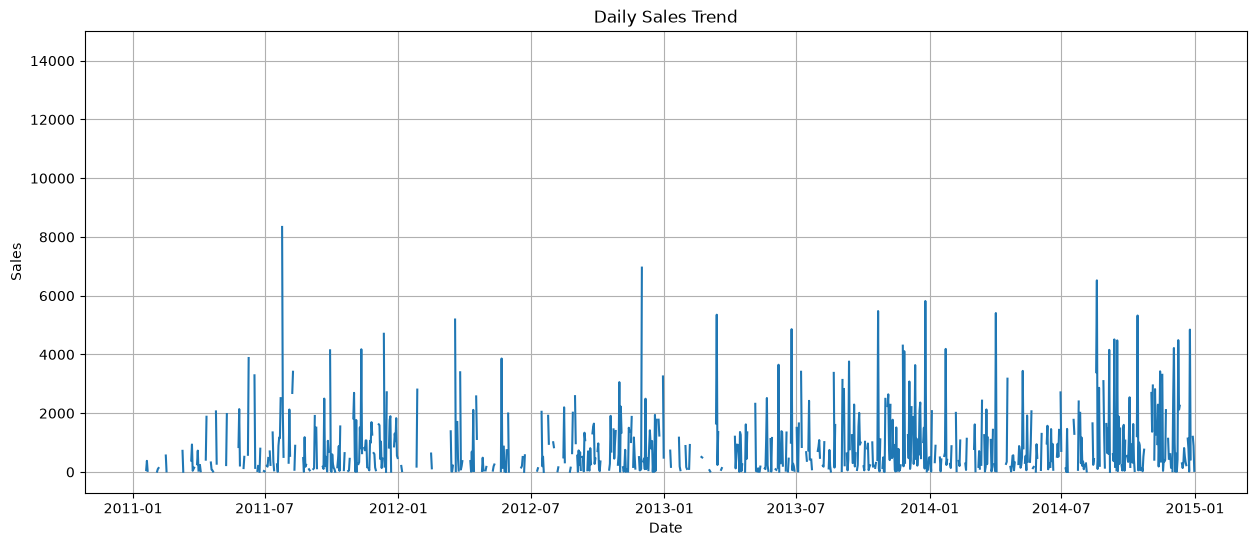

In [36]:
plt.figure(figsize=(15,6))
plt.plot(daily_sales["Sales"])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [41]:
monthly_sales = daily_sales.resample("ME")["Sales"].sum()

In [42]:
monthly_sales.head()

2011-01-31     2648.057
2011-02-28     1348.622
2011-03-31    11008.898
2011-04-30     9343.487
2011-05-31     6570.438
Freq: ME, Name: Sales, dtype: float64

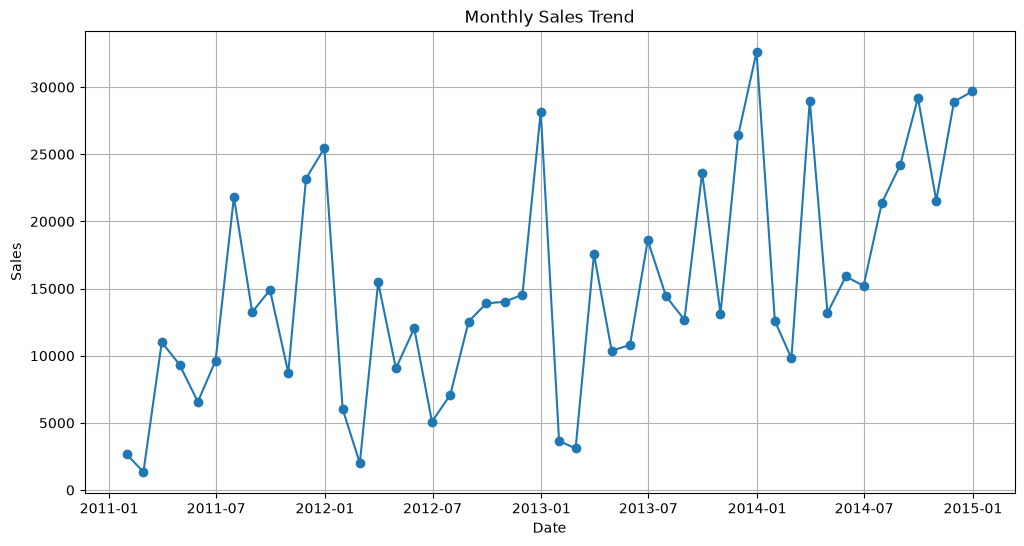

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

## Rolling Mean

The rolling mean smooths short-term fluctuations and helps visualize the long-term trend in sales.

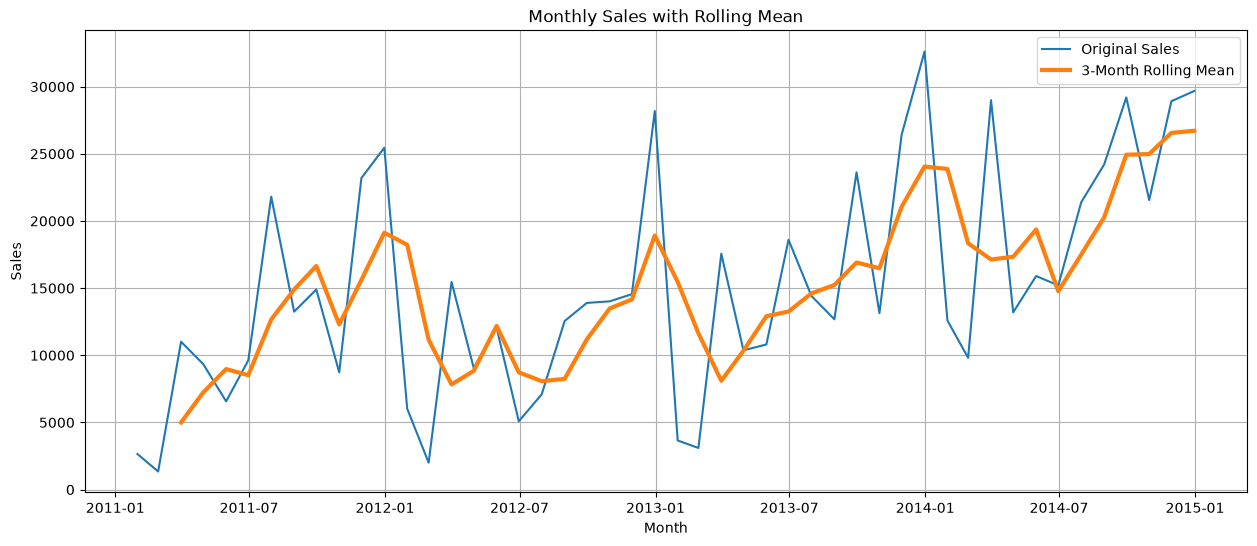

In [52]:
rolling_mean = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(15,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         label="Original Sales")

plt.plot(rolling_mean.index,
         rolling_mean.values,
         linewidth=3,
         label="3-Month Rolling Mean")

plt.title("Monthly Sales with Rolling Mean")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

## Rolling Standard Deviation

Rolling standard deviation helps understand changes in the variability of sales over time.

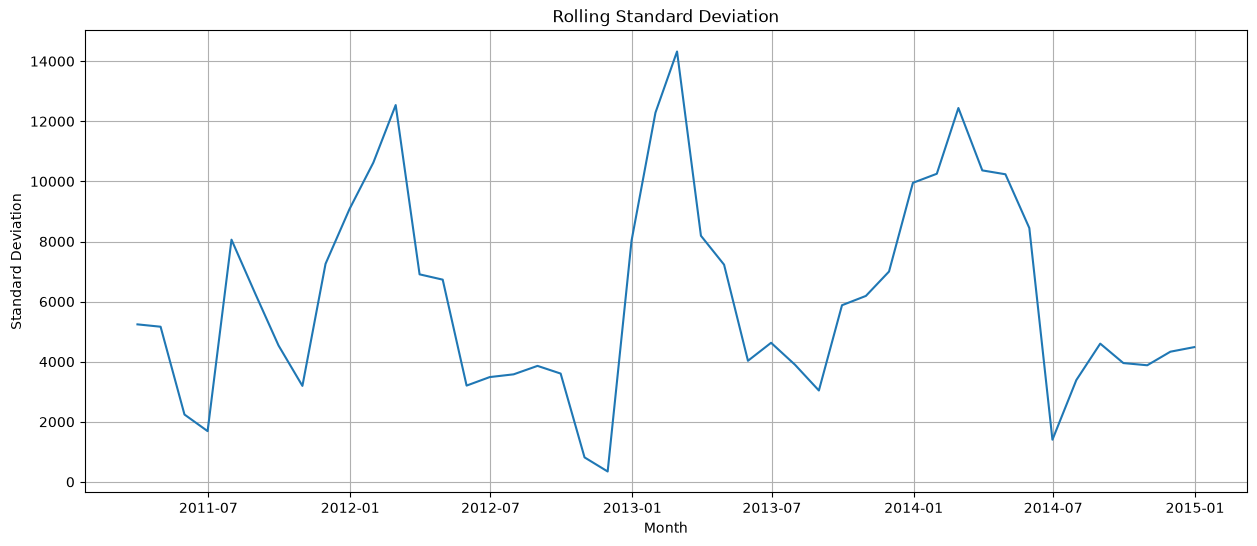

In [53]:
rolling_std = monthly_sales.rolling(window=3).std()

plt.figure(figsize=(15,6))

plt.plot(rolling_std.index,
         rolling_std.values)

plt.title("Rolling Standard Deviation")
plt.xlabel("Month")
plt.ylabel("Standard Deviation")
plt.grid(True)

plt.show()

## Stationarity Test (ADF Test)

The ADF test checks whether the time series is stationary.

In [54]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("P-value :", result[1])

print("\nCritical Values")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -1.8828958702786738
P-value : 0.3401497156580721

Critical Values
1% : -3.584828853223594
5% : -2.9282991495198907
10% : -2.6023438271604937


## Seasonal Decomposition

Decompose the time series into trend, seasonal, and residual components.

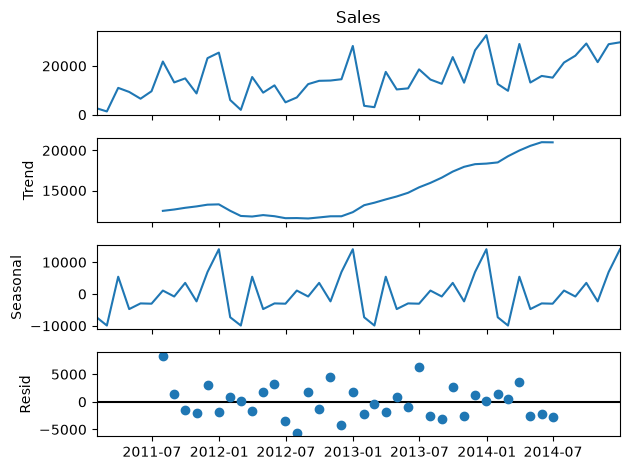

In [56]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

decomposition.plot()

plt.show()

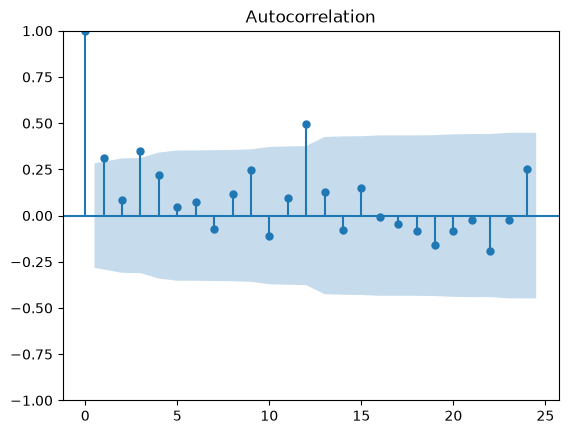

In [57]:
## Autocorrelation Function (ACF)
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(monthly_sales, lags=24)

plt.show()

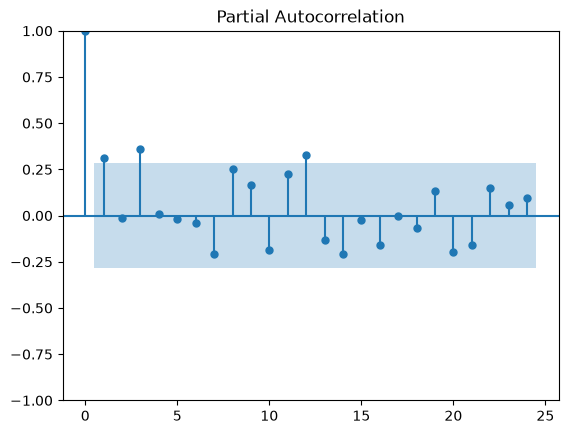

In [58]:
## Partial Autocorrelation Function (PACF)
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(monthly_sales,
          lags=24)

plt.show()

In [59]:
## Save the Processed Dataset
daily_sales.reset_index().to_excel(
    "../data/processed/daily_sales.xlsx",
    index=False
)

print("daily_sales.xlsx saved successfully.")

daily_sales.xlsx saved successfully.


# Business Insights

## Key Findings

- Daily transaction data was aggregated into monthly sales.
- The rolling mean highlights the long-term sales trend.
- Rolling standard deviation reveals changes in sales variability.
- The ADF test determines whether the series is stationary.
- Seasonal decomposition separates trend, seasonality, and residual components.
- ACF and PACF plots provide insights into temporal correlations, which are useful when selecting time-series models.
- The processed dataset has been saved and is ready for the next stage: Feature Engineering.